In [25]:
#read the data

file = open('adult.data', 'r')
def chr_int(a):
    if a.isdigit(): return int(a)
    else:   return 0

data = []
for line in file:
    data1 = line.split(',')
    if len(data1) == 15:
        data.append([chr_int(data1[0]), data1[1],
                    chr_int(data1[2]), data1[3],
                    chr_int(data1[4]), data1[5],
                    data1[6], data1[7], data1[8],
                    data1[9], chr_int(data1[10]),
                    chr_int(data1[11]),
                    chr_int(data1[12]),
                    data1[13], data1[14]
                    ])

In [26]:
print(data[0:2])

[[39, ' State-gov', 0, ' Bachelors', 0, ' Never-married', ' Adm-clerical', ' Not-in-family', ' White', ' Male', 0, 0, 0, ' United-States', ' <=50K\n'], [50, ' Self-emp-not-inc', 0, ' Bachelors', 0, ' Married-civ-spouse', ' Exec-managerial', ' Husband', ' White', ' Male', 0, 0, 0, ' United-States', ' <=50K\n']]


In [27]:
import pandas as pd
df = pd.DataFrame(data)
df.columns = [
        'age', 'type_employer', 'fnlwgt',
        'education', 'education_num', 'marital',
        'occupation', 'relationship', 'race',
        'sex', 'capital_gain', 'capital_loss',
        'hr_per_week', 'country', 'income'
    ]


In [28]:
df.head()

,age,type_employer,fnlwgt,education,education_num,marital,occupation,relationship,race,sex,capital_gain,capital_loss,hr_per_week,country,income
0,39,State-gov,0,Bachelors,0,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,0,United-States,<=50K\n
1,50,Self-emp-not-inc,0,Bachelors,0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K\n
2,38,Private,0,HS-grad,0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,0,United-States,<=50K\n
3,53,Private,0,11th,0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,0,United-States,<=50K\n
4,28,Private,0,Bachelors,0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,0,Cuba,<=50K\n


In [29]:
counts = df.groupby('country').size()
print(counts.head())

country
?           583
Cambodia     19
Canada      121
China        75
Columbia     59
dtype: int64


In [30]:
df.sex.value_counts()

print(len(df))
print(df['sex'].dtype)
print(repr(df['sex'].iloc[0]))
print((df['sex'] == ' Male').sum())

32561
object
' Male'
21790


In [31]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

In [32]:
ml = df[df.sex == 'Male']
ml1 = df[(df.sex == 'Male') & (df.income == '>50K')]



In [33]:
ml1 = df[(df.sex == 'Male') & (df.income == '>50K')]
fm = df[df.sex == 'Female']
fm1 = df[(df.sex == 'Female') &  (df.income == '>50K')]
df1 = df[(df.income == '>50K')]

print('The rate of people with high income is: '  ,int(len(df1) / float(len(df)) * 100))
print('The rate of men with high income is: ' ,int(len(ml1) / float(len(ml)) * 100))
print('The rate of women with high income is: ' ,int(len(fm1) / float(len(fm)) * 100))

The rate of people with high income is:  24
The rate of men with high income is:  30
The rate of women with high income is:  10


In [34]:
print('The average age of men is: ', ml['age'].mean())
print('The average age of women is: ', fm['age'].mean())
print('The average age of high-income men is: ', ml1['age'].mean())
print('The average age of high-income women is: ', fm1['age'].mean())

The average age of men is:  39.43354749885268
The average age of women is:  36.85823043357163
The average age of high-income men is:  44.62578805163614
The average age of high-income women is:  42.125530110262936


In [35]:
ml_mu = ml['age'].mean()
fm_mu = fm['age'].mean()
ml_var = ml['age'].var()
fm_var = fm['age'].var()
ml_std = ml['age'].std()
fm_std = fm['age'].std()
print('Statistics of age for men: mu:', ml_mu, 'var:', ml_var, 'std:', ml_std)
print('Statistics of age for women: mu:', fm_mu, 'var:', fm_var, 'std:', fm_std)

Statistics of age for men: mu: 39.43354749885268 var: 178.77375174530096 std: 13.37063019252649
Statistics of age for women: mu: 36.85823043357163 var: 196.3837063948037 std: 14.01369709943824


In [36]:
ml_median = ml['age'].median()
fm_median = fm['age'].median()
print("Median age per men and women: ",
ml_median, fm_median)
ml_median_age = ml1['age'].median()
fm_median_age = fm1['age'].median()
print("Median age per men and women with high-income: ",
ml_median_age, fm_median_age)

Median age per men and women:  38.0 35.0
Median age per men and women with high-income:  44.0 41.0


<Axes: >

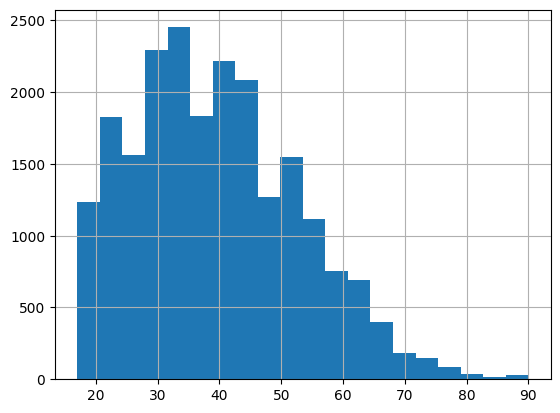

In [37]:
ml_age = ml['age']
ml_age.hist(histtype = 'stepfilled', bins = 20)

<Axes: >

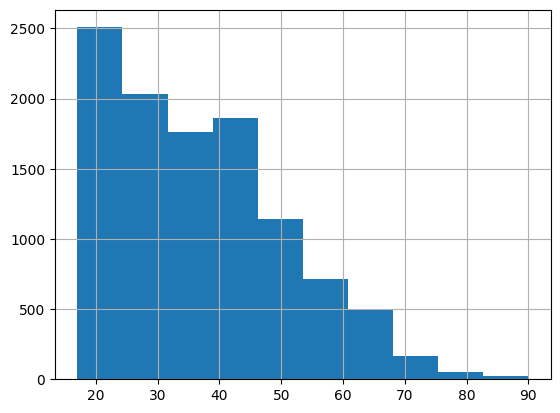

In [38]:
fm_age = fm['age']
fm_age.hist(histtype = 'stepfilled', bins = 10)

<Axes: >

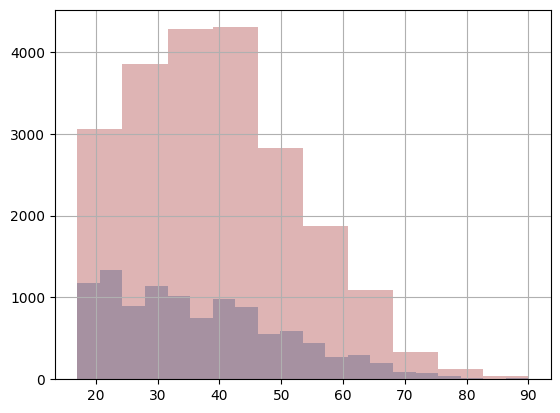

In [39]:
import seaborn as sns

fm_age.hist(histtype = 'stepfilled' , alpha = .5, bins = 20)
ml_age.hist(histtype = 'stepfilled', alpha = .5,
color = sns.desaturate("indianred", .75), bins = 10)

<Axes: >

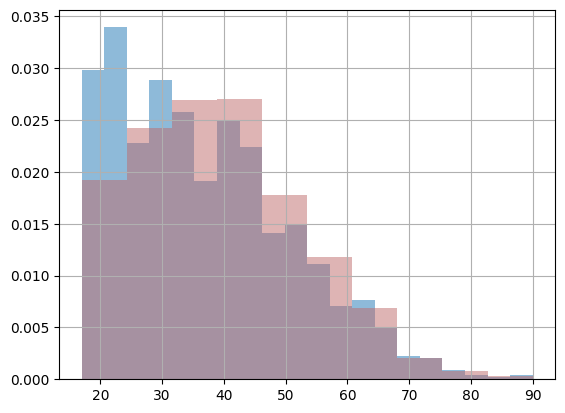

In [40]:
fm_age.hist(density = True, histtype = 'stepfilled', alpha = .5, bins = 20)
ml_age.hist(density = True, histtype = 'stepfilled', alpha = .5, bins = 10,
color = sns.desaturate("indianred", .75))

<Axes: >

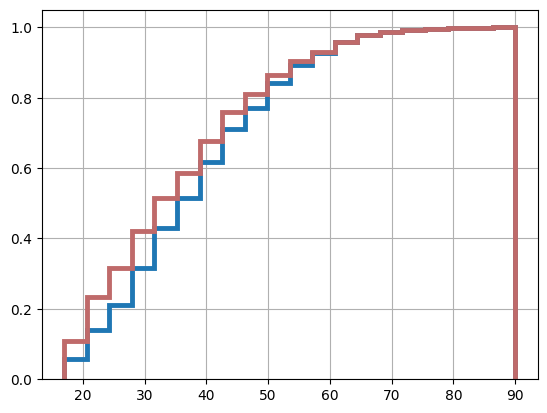

In [41]:
ml_age.hist(density=1, histtype='step', cumulative=True, linewidth=3.5, bins=20)
fm_age.hist(density=1, histtype='step', cumulative=True, linewidth=3.5, bins=20,
            color=sns.desaturate("indianred", .75))

In [42]:
df2 = df.drop(df.index[(df.income == '>50K') & (df['age'] > df['age'].median() + 35) & (df['age'] > df['age'].median() -15)])
ml1_age = ml1['age'] 
fm1_age = fm1['age'] 
ml2_age = ml1_age.drop(ml1_age.index[(ml1_age > df['age'].median() + 35) & (ml1_age > df['age'].median() - 15)])
fm2_age = fm1_age.drop(fm1_age.index[(fm1_age > df['age'].median() + 35) &(fm1_age > df['age'].median() - 15)])

In [43]:
mu2ml = ml2_age.mean()
std2ml = ml2_age.std()
md2ml = ml2_age.median()
mu2fm = fm2_age.mean()
std2fm = fm2_age.std()
md2fm = fm2_age.median()
print("Men statistics:")
print("Mean:", mu2ml, "Std:", std2ml)
print("Median:", md2ml)
print("Min:", ml2_age.min(), "Max:", ml2_age.max())
print("Women statistics:")
print("Mean:", mu2fm, "Std:", std2fm)
print("Median:", md2fm)
print("Min:", fm2_age.min(), "Max:", fm2_age.max())

Men statistics:
Mean: 44.317982123920615 Std: 10.019749857171412
Median: 44.0
Min: 19 Max: 72
Women statistics:
Mean: 41.877028181041844 Std: 10.036441807343714
Median: 41.0
Min: 19 Max: 72


<Axes: >

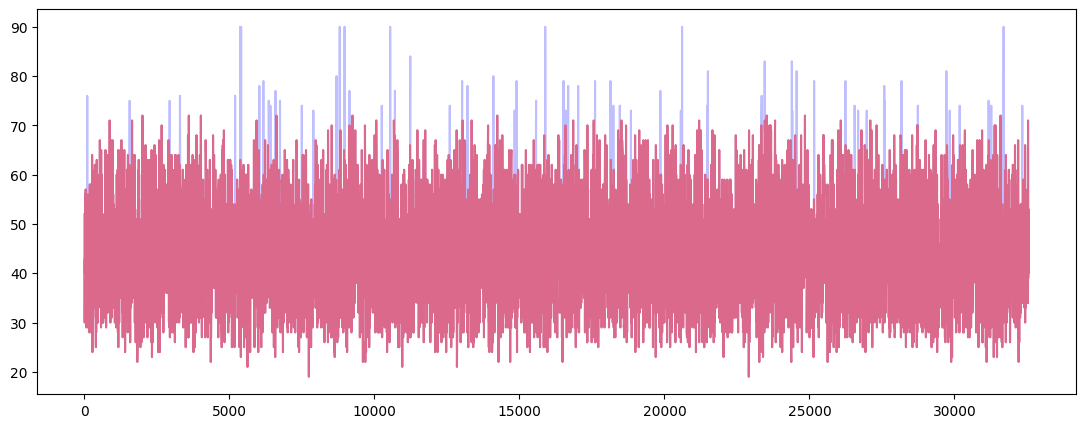

In [46]:
import matplotlib.pyplot as plt
plt.figure(figsize = (13.4, 5))
df.age[(df.income == '>50K')].plot(alpha = .25, color = 'blue')
df2.age[(df2.income == '>50K')].plot(alpha = .45, color = 'red')

In [47]:
print("The mean difference with outliers is: %4.2f." % (ml_age.mean() - fm_age.mean()))
print("The mean difference without outliers is: %4.2f." % (ml2_age.mean() - fm2_age.mean()))

The mean difference with outliers is: 2.58.
The mean difference without outliers is: 2.44.


In [49]:
def skewness(x):
    res = 0
    m = x.mean()
    s = x.std()
    for i in x:
        res += (i-m) * (i-m) * (i-m)
    res /= (len(x) * s * s * s)
    return res
print("Skewness of the male population = ", skewness(ml2_age))
print("Skewness of the female population is = ", skewness(fm2_age))

Skewness of the male population =  0.2664443838432819
Skewness of the female population is =  0.38633352491285977


In [50]:
def pearson(x):
    return 3*(x.mean() - x.median())*x.std()
print("Pearson’s coefficient of the male population = ", pearson(ml2_age))
print("Pearson’s coefficient of the female population = ", pearson(fm2_age))

Pearson’s coefficient of the male population =  9.55830402220993
Pearson’s coefficient of the female population =  26.40672690728092
